In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os

print("Notebook files:")
print(os.listdir("."))

Notebook files:
['01_Data_Loading_Cleaning.ipynb', '02_Feature_Engineering.ipynb', '03_Exploratory_Data_Analysis.ipynb', '04_Customer_RFM_Analysis.ipynb', '05_Customer_Segmentation.ipynb', '06_Sales_Forecasting.ipynb', '07_Churn_Prediction.ipynb', '08_LSTM_Forecasting.ipynb', '09_Inventory_Optimization.ipynb', '10_Hybrid_Forecasting.ipynb', 'Customer_RFM.csv', 'Customer_Segments.csv', 'Inventory_Recommendations.csv', 'LSTM_Future_Forecast.csv', 'Retail_Cleaned.csv', 'Retail_Feature_Engineered.csv', 'Sales_Forecast.csv']


In [4]:
import os

for file in os.listdir("."):
    print(file)

01_Data_Loading_Cleaning.ipynb
02_Feature_Engineering.ipynb
03_Exploratory_Data_Analysis.ipynb
04_Customer_RFM_Analysis.ipynb
05_Customer_Segmentation.ipynb
06_Sales_Forecasting.ipynb
07_Churn_Prediction.ipynb
08_LSTM_Forecasting.ipynb
09_Inventory_Optimization.ipynb
10_Hybrid_Forecasting.ipynb
Customer_RFM.csv
Customer_Segments.csv
Inventory_Recommendations.csv
LSTM_Future_Forecast.csv
Retail_Cleaned.csv
Retail_Feature_Engineered.csv
Sales_Forecast.csv


In [5]:
prophet_df = pd.read_csv("Sales_Forecast.csv")

prophet_df.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-31,567651.785766,296335.193919,807215.468323,567651.785766,567651.785766,0.0,0.0,0.0,0.0,0.0,0.0,567651.785766
1,2010-01-31,586167.083545,318606.252741,839641.319097,586167.083545,586167.083545,0.0,0.0,0.0,0.0,0.0,0.0,586167.083545
2,2010-02-28,602890.578373,341457.219199,878494.214687,602890.578373,602890.578373,0.0,0.0,0.0,0.0,0.0,0.0,602890.578373
3,2010-03-31,621405.876153,337934.144833,885087.473638,621405.876153,621405.876153,0.0,0.0,0.0,0.0,0.0,0.0,621405.876153
4,2010-04-30,639323.906160,364756.140720,900487.697732,639323.906160,639323.906160,0.0,0.0,0.0,0.0,0.0,0.0,639323.906160


In [6]:
lstm_df = pd.read_csv("LSTM_Future_Forecast.csv")

lstm_df.head()

,ds,PredictedSales
0,2010-12-10,20075.752
1,2010-12-11,19945.215
2,2010-12-12,19891.492
3,2010-12-13,19919.713
4,2010-12-14,20013.470


In [7]:
print("LSTM columns:")
print(lstm_df.columns.tolist())

LSTM columns:
['ds', 'PredictedSales']


In [8]:
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
lstm_df["ds"] = pd.to_datetime(lstm_df["ds"])

In [9]:
hybrid_df = pd.merge(
    prophet_df[["ds", "yhat"]],
    lstm_df[["ds", "PredictedSales"]],
    on="ds",
    how="inner"
)

print("Hybrid data shape:", hybrid_df.shape)
hybrid_df.head()

Hybrid data shape: (1, 3)


,ds,yhat,PredictedSales
0,2010-12-31,785654.485298,20361.248


In [10]:
hybrid_df["HybridPrediction"] = (
    0.5 * hybrid_df["yhat"] +
    0.5 * hybrid_df["PredictedSales"]
)

hybrid_df.head(10)

,ds,yhat,PredictedSales,HybridPrediction
0,2010-12-31,785654.485298,20361.248,403007.866649


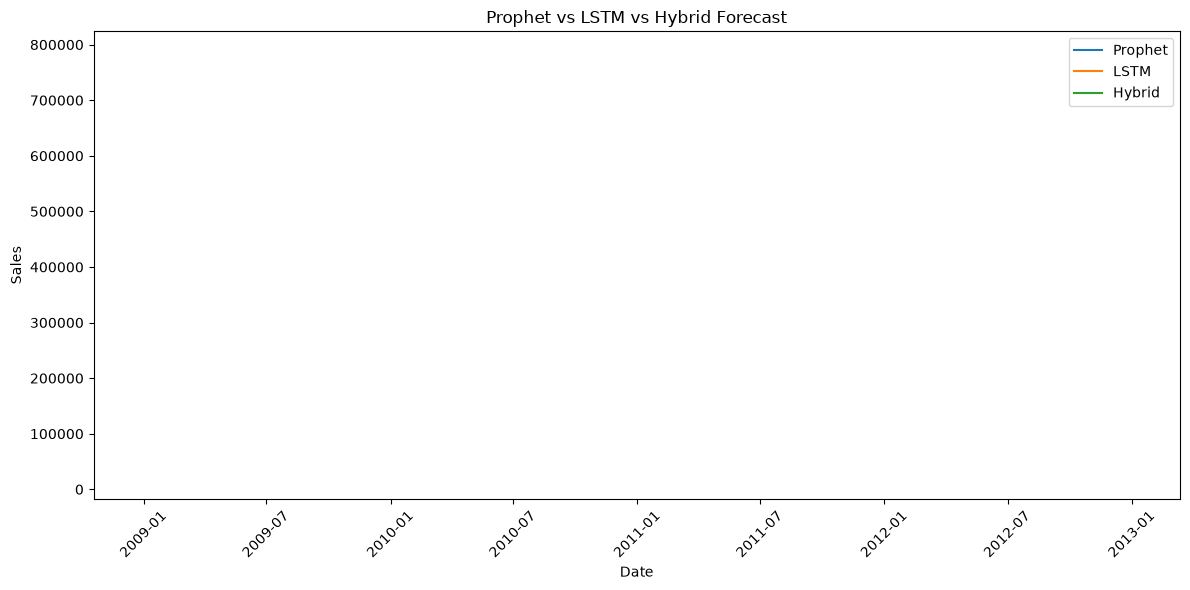

In [11]:
plt.figure(figsize=(12, 6))

plt.plot(
    hybrid_df["ds"],
    hybrid_df["yhat"],
    label="Prophet"
)

plt.plot(
    hybrid_df["ds"],
    hybrid_df["PredictedSales"],
    label="LSTM"
)

plt.plot(
    hybrid_df["ds"],
    hybrid_df["HybridPrediction"],
    label="Hybrid"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Prophet vs LSTM vs Hybrid Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
print("Prophet range:")
print(prophet_df["yhat"].min(), prophet_df["yhat"].max())

print("\nLSTM range:")
print(lstm_df["PredictedSales"].min(), lstm_df["PredictedSales"].max())

Prophet range:
567651.7857663872 1003657.1842185092

LSTM range:
19891.492 20579.53


In [13]:
print(prophet_df[["ds", "yhat"]].tail(10))
print(lstm_df[["ds", "PredictedSales"]].head(10))

           ds          yhat
15 2011-03-31  8.394086e+05
16 2011-04-30  8.573266e+05
17 2011-05-31  8.758419e+05
18 2011-06-30  8.937599e+05
19 2011-07-31  9.122752e+05
20 2011-08-31  9.307905e+05
21 2011-09-30  9.487086e+05
22 2011-10-31  9.672239e+05
23 2011-11-30  9.851419e+05
24 2011-12-31  1.003657e+06
          ds  PredictedSales
0 2010-12-10       20075.752
1 2010-12-11       19945.215
2 2010-12-12       19891.492
3 2010-12-13       19919.713
4 2010-12-14       20013.470
5 2010-12-15       20123.512
6 2010-12-16       20234.832
7 2010-12-17       20330.684
8 2010-12-18       20417.146
9 2010-12-19       20485.643


In [15]:
import pandas as pd

prophet_df = pd.read_csv("Prophet_Daily_Future_Forecast.csv")
lstm_df = pd.read_csv("LSTM_Future_Forecast.csv")

prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])
lstm_df["ds"] = pd.to_datetime(lstm_df["ds"])

print("Prophet:", prophet_df.shape)
print("LSTM:", lstm_df.shape)

print(prophet_df.head())
print(lstm_df.head())

Prophet: (30, 4)
LSTM: (30, 2)
          ds          yhat    yhat_lower    yhat_upper
0 2010-12-10  41592.352730  27114.199074  55149.401152
1 2010-12-11  27858.539505  13169.943879  42738.544827
2 2010-12-12  36704.168351  21444.506586  50190.860170
3 2010-12-13  46478.511792  31953.371228  60950.964382
4 2010-12-14  48406.141174  34052.121554  62513.694113
          ds  PredictedSales
0 2010-12-10       20075.752
1 2010-12-11       19945.215
2 2010-12-12       19891.492
3 2010-12-13       19919.713
4 2010-12-14       20013.470


In [16]:
hybrid_df = pd.merge(
    prophet_df[["ds", "yhat"]],
    lstm_df[["ds", "PredictedSales"]],
    on="ds",
    how="inner"
)

hybrid_df["HybridPrediction"] = (
    0.5 * hybrid_df["yhat"] +
    0.5 * hybrid_df["PredictedSales"]
)

hybrid_df.head(10)

,ds,yhat,PredictedSales,HybridPrediction
0,2010-12-10,41592.352730,20075.752,30834.052365
1,2010-12-11,27858.539505,19945.215,23901.877252
2,2010-12-12,36704.168351,19891.492,28297.830176
3,2010-12-13,46478.511792,19919.713,33199.112396
4,2010-12-14,48406.141174,20013.470,34209.805587
5,2010-12-15,45549.724226,20123.512,32836.618113
6,2010-12-16,52612.668866,20234.832,36423.750433
7,2010-12-17,42622.376996,20330.684,31476.530498
8,2010-12-18,28888.563771,20417.146,24652.854886
9,2010-12-19,37734.192617,20485.643,29109.917809


In [17]:
print("Hybrid rows:", len(hybrid_df))
print(hybrid_df)

Hybrid rows: 30
           ds          yhat  PredictedSales  HybridPrediction
0  2010-12-10  41592.352730       20075.752      30834.052365
1  2010-12-11  27858.539505       19945.215      23901.877252
2  2010-12-12  36704.168351       19891.492      28297.830176
3  2010-12-13  46478.511792       19919.713      33199.112396
4  2010-12-14  48406.141174       20013.470      34209.805587
5  2010-12-15  45549.724226       20123.512      32836.618113
6  2010-12-16  52612.668866       20234.832      36423.750433
7  2010-12-17  42622.376996       20330.684      31476.530498
8  2010-12-18  28888.563771       20417.146      24652.854886
9  2010-12-19  37734.192617       20485.643      29109.917809
10 2010-12-20  47508.536058       20530.863      34019.699529
11 2010-12-21  49436.165440       20570.764      35003.464720
12 2010-12-22  46579.748492       20579.530      33579.639246
13 2010-12-23  53642.693132       20574.693      37108.693066
14 2010-12-24  43652.401262       20552.871      32102

In [18]:
hybrid_df.to_csv(
    "Hybrid_Future_Forecast.csv",
    index=False
)

print("✅ Hybrid forecast saved successfully!")

✅ Hybrid forecast saved successfully!


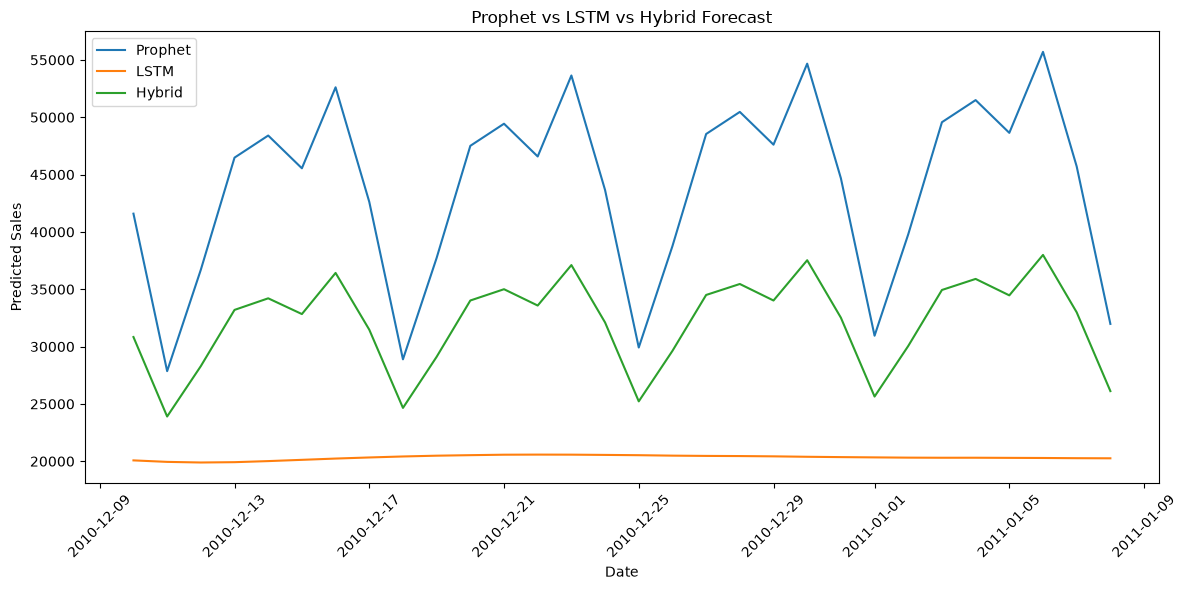

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    hybrid_df["ds"],
    hybrid_df["yhat"],
    label="Prophet"
)

plt.plot(
    hybrid_df["ds"],
    hybrid_df["PredictedSales"],
    label="LSTM"
)

plt.plot(
    hybrid_df["ds"],
    hybrid_df["HybridPrediction"],
    label="Hybrid"
)

plt.xlabel("Date")
plt.ylabel("Predicted Sales")
plt.title("Prophet vs LSTM vs Hybrid Forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()